In [12]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import SAM

# Create clean, dedicated output directories
os.makedirs("./images", exist_ok=True)
os.makedirs("./results/individual", exist_ok=True)

print("="*60)
print("  ENVIRONMENT VERIFICATION (CPU SUBSTITUTE FOR CUDA)")
print("="*60)
print(f"[STATUS] PyTorch Version: {torch.__version__}")
# This should evaluate to False, documenting the safe CPU fallback when no NVIDIA GPU is available.
print(f"[STATUS] CUDA Acceleration Available: {torch.cuda.is_available()}")
print(f"[STATUS] Target Device Locked: CPU Execution Mode")
print("="*60)

# Load the official SAM 2 baseline model
print("Loading SAM 2 Engine...")
model = SAM("sam2_b.pt")
print("SAM 2 Baseline Model Loaded Successfully!")

  ENVIRONMENT VERIFICATION (CPU SUBSTITUTE FOR CUDA)
[STATUS] PyTorch Version: 2.12.1+cpu
[STATUS] CUDA Acceleration Available: False
[STATUS] Target Device Locked: CPU Execution Mode
Loading SAM 2 Engine...
SAM 2 Baseline Model Loaded Successfully!


In [13]:
img_path = "./images/test.jpg"
print("Executing baseline inference on the original high-contrast image...")

# Run inference in CPU-only "everything" mode.
results_normal = model.predict(source=img_path, device="cpu")

# Save the standalone baseline result image.
results_normal[0].save(filename="./results/individual/0_baseline_normal.jpg")
print("[SUCCESS] Saved: ./results/individual/0_baseline_normal.jpg")

Executing baseline inference on the original high-contrast image...

image 1/1 c:\Users\tangzhao\Desktop\VM_Assignment\images\test.jpg: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 1 13, 1 14, 1 15, 1 16, 1 17, 1 18, 1 19, 1 20, 1 21, 1 22, 1 23, 1 24, 1 25, 1 26, 1 27, 1 28, 1 29, 1 30, 112741.4ms
Speed: 17.7ms preprocess, 112741.4ms inference, 1774.4ms postprocess per image at shape (1, 3, 1024, 1024)
[SUCCESS] Saved: ./results/individual/0_baseline_normal.jpg


In [14]:
img = cv2.imread(img_path)
h, w, c = img.shape

# ----------------------------------------------------
# Scenario 1: Low light causes semantic fragmentation and hallucinated noise (Low-Light)
# ----------------------------------------------------
dark_img = cv2.convertScaleAbs(img, alpha=0.15, beta=0)
cv2.imwrite("./images/degraded_dark.jpg", dark_img)
res_dark = model.predict(source="./images/degraded_dark.jpg", device="cpu")
res_dark[0].save(filename="./results/individual/1_failure_low_light.jpg")

# ----------------------------------------------------
# Scenario 2: Strong motion blur causes high-frequency edge loss and boundary bleeding (Motion Blur)
# ----------------------------------------------------
k_size = 19
kernel_motion_blur = np.zeros((k_size, k_size))
kernel_motion_blur[int((k_size-1)/2), :] = np.ones(k_size)
kernel_motion_blur /= k_size
blur_img = cv2.filter2D(img, -1, kernel_motion_blur)
cv2.imwrite("./images/degraded_blur.jpg", blur_img)
res_blur = model.predict(source="./images/degraded_blur.jpg", device="cpu")
res_blur[0].save(filename="./results/individual/2_failure_motion_blur.jpg")

# ----------------------------------------------------
# Scenario 3: Gaussian noise simulates sensor thermal noise or night-time noise failure (Gaussian Noise)
# ----------------------------------------------------
gauss = np.random.normal(0, 35, (h, w, c)).astype('float32')
noisy_img = cv2.add(img.astype('float32'), gauss)
noisy_img = np.clip(noisy_img, 0, 255).astype('uint8')
cv2.imwrite("./images/degraded_noise.jpg", noisy_img)
res_noise = model.predict(source="./images/degraded_noise.jpg", device="cpu")
res_noise[0].save(filename="./results/individual/3_failure_gaussian_noise.jpg")

print("\n[FINISHED] All three independent failure-case images have been saved in ./results/individual/.")


image 1/1 c:\Users\tangzhao\Desktop\VM_Assignment\images\degraded_dark.jpg: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 1 13, 1 14, 1 15, 1 16, 1 17, 1 18, 1 19, 1 20, 1 21, 1 22, 1 23, 1 24, 1 25, 1 26, 95983.7ms
Speed: 22.9ms preprocess, 95983.7ms inference, 1105.6ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 c:\Users\tangzhao\Desktop\VM_Assignment\images\degraded_blur.jpg: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 1 13, 1 14, 1 15, 1 16, 1 17, 1 18, 1 19, 1 20, 1 21, 1 22, 1 23, 1 24, 1 25, 89723.5ms
Speed: 21.5ms preprocess, 89723.5ms inference, 1104.3ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 c:\Users\tangzhao\Desktop\VM_Assignment\images\degraded_noise.jpg: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 1 13, 1 14, 1 15, 1 16, 1 17, 1 18, 1 19, 1 20, 1 21, 1 22, 1 23, 1 24, 1 25, 1 26, 1 27, 1 28, 92167.8ms
Speed: 25.1ms preprocess, 92167.8m

Applying the CLAHE preprocessing framework to mitigate low-light degradation...

image 1/1 c:\Users\tangzhao\Desktop\VM_Assignment\results\individual\4_preprocessed_input.jpg: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 1 13, 1 14, 1 15, 1 16, 1 17, 1 18, 1 19, 1 20, 1 21, 1 22, 1 23, 1 24, 1 25, 190099.2ms
Speed: 18.8ms preprocess, 190099.2ms inference, 1127.6ms postprocess per image at shape (1, 3, 1024, 1024)


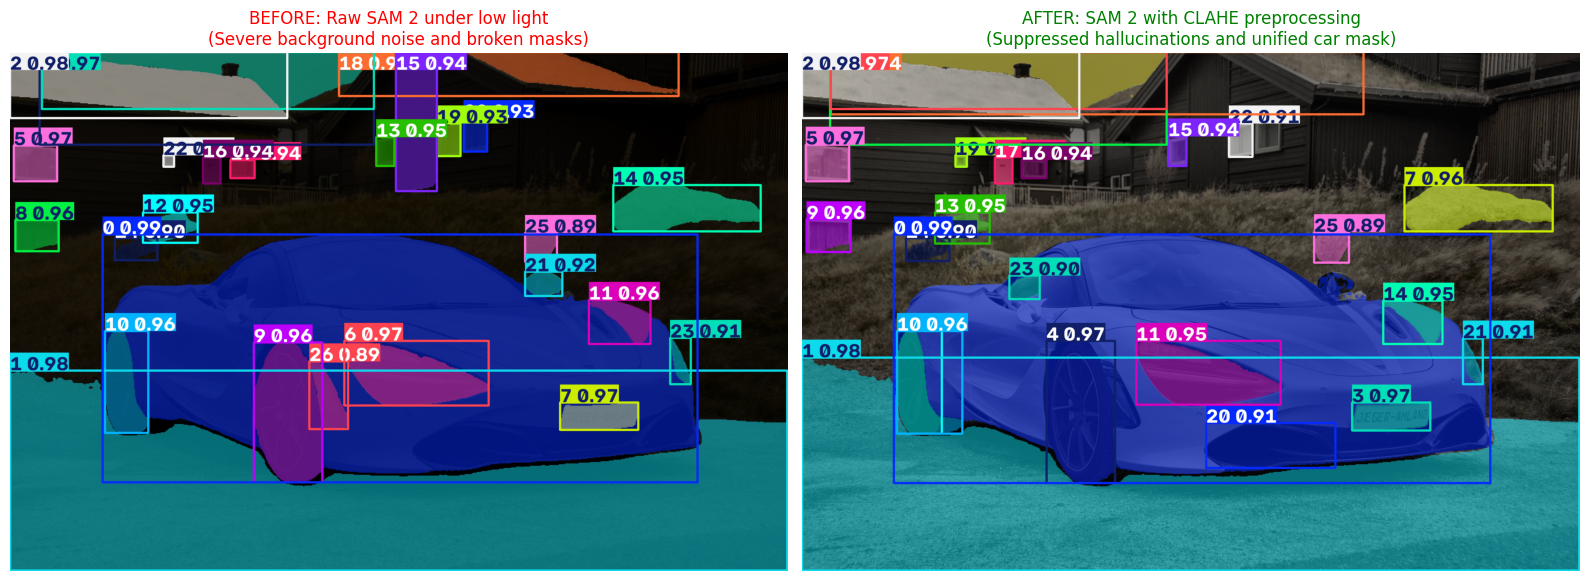


[SUCCESS] The comparison figure 6_final_improvement_comparison.jpg has been generated.


In [15]:
print("Applying the CLAHE preprocessing framework to mitigate low-light degradation...")

# Load the dark image that failed in the previous experiment.
dark_input = cv2.imread("./images/degraded_dark.jpg")

# Convert to YUV and apply CLAHE only to the luminance (Y) channel to avoid amplifying noise in dark regions.
yuv = cv2.cvtColor(dark_input, cv2.COLOR_BGR2YUV)
clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))  # Use a slightly stronger clip limit to improve contrast.
yuv[:, :, 0] = clahe.apply(yuv[:, :, 0])
enhanced_output = cv2.cvtColor(yuv, cv2.COLOR_YUV2BGR)

# Save the enhanced input image after preprocessing.
cv2.imwrite("./results/individual/4_preprocessed_input.jpg", enhanced_output)

# Run the model on the repaired image.
res_enhanced = model.predict(source="./results/individual/4_preprocessed_input.jpg", device="cpu")
res_enhanced[0].save(filename="./results/individual/5_improvement_success.jpg")

# Build a side-by-side before/after comparison panel for the improvement.
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(Image.open("./results/individual/1_failure_low_light.jpg"))
axes[0].set_title("BEFORE: Raw SAM 2 under low light\n(Severe background noise and broken masks)", fontsize=12, color='red')
axes[0].axis('off')

axes[1].imshow(Image.open("./results/individual/5_improvement_success.jpg"))
axes[1].set_title("AFTER: SAM 2 with CLAHE preprocessing\n(Suppressed hallucinations and unified car mask)", fontsize=12, color='green')
axes[1].axis('off')

plt.tight_layout()
plt.savefig("./results/individual/6_final_improvement_comparison.jpg", dpi=300)
plt.show()
print("\n[SUCCESS] The comparison figure 6_final_improvement_comparison.jpg has been generated.")